In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pickle

In [6]:
# Exporting and cleaning the dataset
dfug = pd.read_csv("data/uganda_dataset.csv")

# Filling missing values
dfug.fillna(dfug.median(numeric_only=True), inplace=True)

dfug

,company,year,bankrupt,Attr27,Attr35,Attr21,Attr46,Attr24,Attr25,Attr40,...,Attr11,Attr57,Attr13,Attr16,Attr47,Attr55,Attr6,Attr64,Attr12,Attr48
0,Umeme Ltd,2025,1,-4.089457,-1.222332,0.228980,0.288181,3.215895,-2.663659,0.238296,...,0.995855,-0.822939,0.188446,0.200850,0.000000,-353989,-4.566515,2.034844,0.200850,-1.222332
1,Umeme Ltd,2024,1,-19.814840,-0.416895,1.101358,1.147235,0.111410,0.153907,0.888959,...,0.612863,0.212807,0.657096,1.325815,17.000744,238449,-0.050655,763.194197,0.716396,0.086553
2,Uganda Clays Ltd,2025,0,1.169609,0.056955,1.101505,0.479077,0.144344,0.459792,0.050133,...,0.234623,-0.472330,0.537274,0.438586,144.803307,256377,0.285010,0.529491,1.026118,0.103059
3,Uganda Clays Ltd,2024,1,-0.862229,-0.036208,1.101358,0.436290,0.111410,0.489473,0.051038,...,0.150434,-0.576251,0.411157,0.341079,117.261933,-3231563,0.298906,0.521566,0.435419,0.025463
4,Stanbic Uganda Holdings,2025,0,6.227294,0.064500,1.109578,1.257000,0.118740,0.200013,0.701688,...,0.135266,-51.118515,1.032021,0.162037,41.202638,2356271735,0.180214,14.866936,0.157009,0.068500
5,Stanbic Uganda Holdings,2024,0,7.385634,0.062640,1.101358,1.246437,0.111410,0.192788,0.721931,...,0.133302,-43.688961,1.036256,0.161222,41.202638,2054992014,0.177614,15.738240,0.155581,0.067166
6,DFCU Bank,2025,0,0.754961,0.022621,1.155736,1.245030,0.131112,0.156741,0.824081,...,0.170547,-38.487725,1.036373,0.181398,41.202638,736809,0.131166,3.055139,0.175031,0.027735
7,DFCU Bank,2024,0,0.816714,0.023419,1.101358,1.244618,0.111410,0.153292,0.838323,...,0.159977,-36.097384,1.041467,0.170199,41.202638,681663,0.128759,2.847205,0.163422,0.028863
8,MTN Uganda Ltd,2024,0,3.993233,0.248249,1.101358,0.793691,0.552810,0.251446,0.773897,...,0.614978,-4.798409,0.970087,0.886005,5.025041,-447265632,0.251446,1.090093,1.169701,0.354415
9,MTN Uganda Ltd,2025,0,4.381439,0.258867,1.135950,0.783787,0.555900,0.224681,0.762960,...,0.614982,-7.775369,0.979166,0.854075,3.468013,-577876566,0.224681,1.113784,1.103109,0.361579


Text(0, 0.5, 'Frequency')

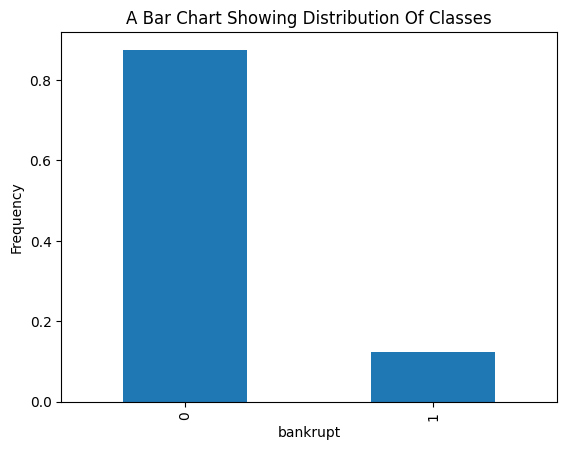

In [7]:
# A Plot showing Distribution of classes
dfug["bankrupt"].value_counts(normalize=True).plot(kind="bar")
plt.title("A Bar Chart Showing Distribution Of Classes")
plt.ylabel("Frequency")

In [14]:
# Preparing features and target variable

X_ug = dfug.drop(columns=['company', 'year', 'bankrupt'])
correct_order = [
    'Attr48', 'Attr12', 'Attr64', 'Attr6', 'Attr55',
    'Attr47', 'Attr16', 'Attr13', 'Attr57', 'Attr11',
    'Attr29', 'Attr58', 'Attr34', 'Attr40', 'Attr25',
    'Attr24', 'Attr46', 'Attr21', 'Attr35', 'Attr27'
]

X_ug = X_ug[correct_order]
y_ug = dfug['bankrupt']

In [11]:
# Loading trained Gradient
with open("models/model_dt2.pkl", "rb") as f:
    model = pickle.load(f)

In [13]:
model.feature_names_in_

array(['Attr48', 'Attr12', 'Attr64', 'Attr6', 'Attr55', 'Attr47',
       'Attr16', 'Attr13', 'Attr57', 'Attr11', 'Attr29', 'Attr58',
       'Attr34', 'Attr40', 'Attr25', 'Attr24', 'Attr46', 'Attr21',
       'Attr35', 'Attr27'], dtype=object)

In [17]:
predictions= model.predict(X_ug)

probabilities = model.predict_proba(X_ug)

In [18]:
dfug['Prediction'] = predictions

dfug['Probability'] = probabilities[:,1]

***Using SHAP for feature Importance and Recommendation system***

In [ ]:
dfug = pd.read_csv("data/uganda_dataset.csv")
dfug.head()
X = dfug.drop(columns=["bankrupt_class","bankrupt_after_years"])
y = dfug["bankrupt_after_years"]
